<a href="https://colab.research.google.com/github/laramalkawi81-ops/DS230-Instacart-Project/blob/main/Copy_of_Copy_of_Copy_of_05_taskA_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task A: Reorder Prediction (Classification)

In this notebook, we train and evaluate multiple classification models to predict whether a user will reorder a product in their next order.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)





from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

DATA_PATH = "/content/drive/MyDrive/instacart_data/instacart_data"
data = pd.read_csv(f"{DATA_PATH}/model_data_sample.csv")

In [ ]:
print(data.shape)
data.head()

(6550242, 19)


,order_id,product_id,add_to_cart_order,reordered,product_freq,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,days_since_prior_order_scaled,total_orders,mean_days_between_orders,product_reorder_rate,product_purchase_count,user_product_count,user_product_reorder_rate,order_hour
0,6,40462,1,0,0.000009,22352,prior,4,1,12,30.0,2.100730,9,21.777778,0.307692,52,1,0.000000,12
1,6,15873,2,0,0.000002,22352,prior,4,1,12,30.0,2.100730,9,21.777778,0.294118,17,1,0.000000,12
2,6,41897,3,0,0.000001,22352,prior,4,1,12,30.0,2.100730,9,21.777778,0.100000,10,1,0.000000,12
3,28,35108,1,0,0.000591,98256,prior,29,3,13,6.0,-0.477496,81,4.456790,0.609198,3892,3,0.666667,13
4,28,40593,2,1,0.000215,98256,prior,29,3,13,6.0,-0.477496,81,4.456790,0.463506,1603,2,0.500000,13


We define the classification target as reordered and exclude idenfifiers to avoid leakage.

In [ ]:
target = 'reordered'
features = [
    'total_orders',
    'mean_days_between_orders',
    'product_reorder_rate',
    'product_purchase_count',
    'user_product_count',
    'user_product_reorder_rate',
    'order_dow',
    'order_hour'
]

X = data[features]
y = data[target]


A time-aware split is used to ensure that training data chronologically precedes validation data.

In [ ]:
train_data = data[data['order_number'] < data['order_number'].quantile(0.8)]
test_data  = data[data['order_number'] >= data['order_number'].quantile(0.8)]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5238960, 8)
Test shape: (1311282, 8)


In [ ]:
#  Standard Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Logistic Regression serves as a strong linear baseline with class weighting to handle imbalance.



Confusion Matrix – Logistic Regression


Logistic Regression Metrics:
Accuracy: 0.8881743210079907
Precision: 0.9703579354867999
Recall: 0.8885970365863107
F1-score: 0.9276794746028623


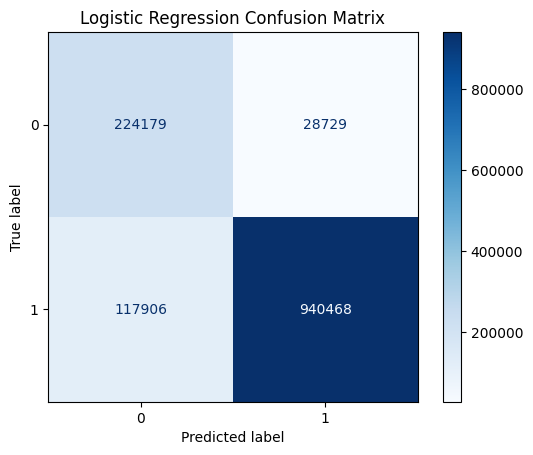

In [ ]:
logreg = LogisticRegression(class_weight='balanced', max_iter=500)
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)
y_prob_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall:", recall_score(y_test, y_pred_logreg))
print("F1-score:", f1_score(y_test, y_pred_logreg))

cm = confusion_matrix(y_test, y_pred_logreg)
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


K-NN

KNN Metrics:
Accuracy: 0.8344940295070016
Precision: 0.9590697136396821
Recall: 0.8303832104719125
F1-score: 0.8900992891711655


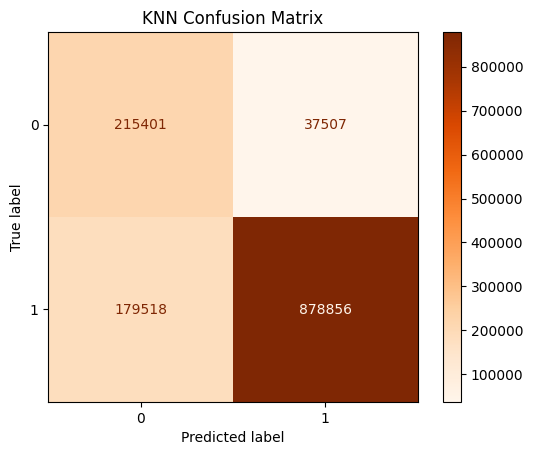

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]
print("KNN Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn).plot(cmap=plt.cm.Oranges)
plt.title("KNN Confusion Matrix")
plt.show()



Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


base_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=1000)
svm_linear = CalibratedClassifierCV(base_model)


svm_linear.fit(X_train_scaled, y_train)

y_pred_svm_linear = svm_linear.predict(X_test_scaled)
y_prob_svm_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]


print("SVM Linear Metrics (Fast Version):")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_linear))
print("Precision:", precision_score(y_test, y_pred_svm_linear))
print("Recall:", recall_score(y_test, y_pred_svm_linear))
print("F1-score:", f1_score(y_test, y_pred_svm_linear))


SVM Linear Metrics (Fast Version):
Accuracy: 0.895855353768297
Precision: 0.9679628477062581
Recall: 0.9007827100816913
F1-score: 0.9331652386613177




A linear SVM was used due to scalability constraints. Non-linear kernels were avoided because of their high computational cost on large datasets

Decision Tree


In [ ]:
dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))



Decision Tree Metrics:
Accuracy: 0.8816074650609098
Precision: 0.9711909894756173
Recall: 0.8794027442095138
F1-score: 0.9230205482169067


 Random Forest


In [ ]:
rf = RandomForestClassifier(n_estimators=10, max_depth=5, class_weight='balanced',n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))



Random Forest Metrics:
Accuracy: 0.9046742043282833
Precision: 0.9626618789909002
Recall: 0.9174809660857126
F1-score: 0.9395285608891791


ROC Curve and AUC Comparison

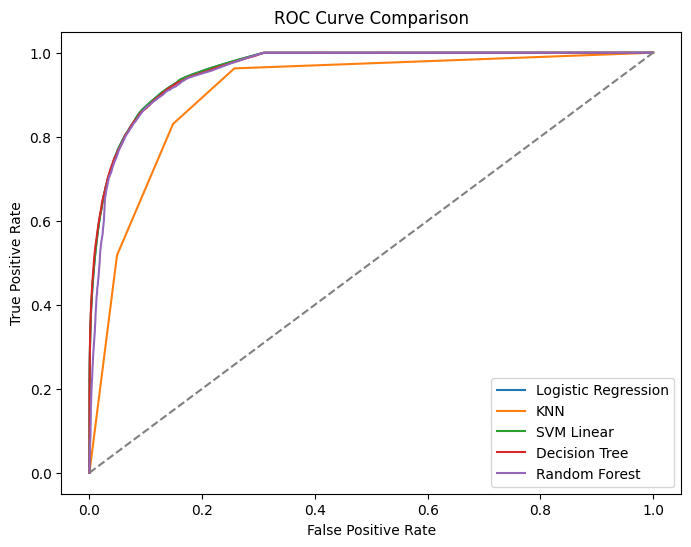

In [ ]:
models_prob = {
    "Logistic Regression": y_prob_logreg,
    "KNN": y_prob_knn,
    "SVM Linear": y_prob_svm_linear,

    "Decision Tree": y_prob_dt,
    "Random Forest": y_prob_rf
}

plt.figure(figsize=(8,6))
for name, probs in models_prob.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()



To evaluate the classification models under different decision thresholds,
ROC curves and AUC scores were computed for the probabilistic models.
This is especially important due to class imbalance in the reorder prediction task.


In [ ]:
from sklearn.metrics import f1_score

print("LR F1:", f1_score(y_test, logreg.predict(X_test_scaled)))
print("KNN F1:", f1_score(y_test, knn.predict(X_test_scaled)))
print("SVM F1:", f1_score(y_test, svm_linear.predict(X_test_scaled)))
print("DT F1:", f1_score(y_test, dt.predict(X_test)))
print("RF F1:", f1_score(y_test, rf.predict(X_test)))


LR F1: 0.9276794746028623
KNN F1: 0.8900992891711655
SVM F1: 0.9331652386613177
DT F1: 0.9230205482169067
RF F1: 0.9395285608891791


In this step, I compared multiple classification models using ROC curves to evaluate their ability to distinguish between reordered and non-reordered products. Random Forest and Logistic Regression showed better trade-offs compared to simpler models like KNN